# Dunnhumby: The Complete Journey | 05 Retention and Churn

Measures how long households keep shopping regularly before they lapse, and which early behaviour predicts an earlier lapse.

**Why survival analysis instead of classic cohorts:** households joined the panel gradually (notebook 02), so their first week in the data is enrolment, not acquisition. Survival analysis handles this correctly. It also handles households still shopping at the end of the data (right censoring), which a simple churn rate would treat as if they had been observed forever.

**Design, chosen to avoid look-ahead bias**
- **Baseline:** weeks 16 to 27. Behaviour features are measured only here.
- **Follow-up:** from the start of week 28 to the end of week 101.
- **Lapse, measured against each household's own rhythm:** a household has lapsed when it goes without a visit for more than **3 of its usual shopping cycles**, where the usual cycle is 7 days divided by its baseline trips per week. The threshold has a floor of 23 days (the 95th percentile of all visit gaps, notebook 03) and a cap of 91 days (a full quarter away counts as a lapse for anyone). A 4-cycle rule is tested as a sensitivity check.
- A lapse is only counted if the whole threshold period after the last visit is inside the data. Households that never lapse are censored at the last day where a lapse could still be observed.

**Why a personal threshold:** a first version used a fixed 23-day threshold for everyone. Light shoppers visit about once every 3 weeks, so 23 days is their normal rhythm: 98% of them were flagged as lapsed, most on day one, and 99% of all "lapsed" households came back. The model was measuring shopping frequency, not lapsing. The 23-day figure was also a poor fit for light shoppers because it pools all visit gaps, and heavy shoppers contribute far more gaps than anyone else. The diagnostic in section 2 shows this directly.

RFM segments from notebook 04 are **not** used as predictors, because they were built from the whole period, including the follow-up. Using them would let the model see the future.

**Outputs:** `data/processed/household_lapse.parquet` and 3 charts in `outputs/figures/` (`05_*.png`).

In [1]:
!pip -q install -U duckdb lifelines
from google.colab import drive
from pathlib import Path
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, proportional_hazard_test
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
drive.mount('/content/drive')
PROJ = Path('/content/drive/MyDrive/Dunnhumby Project')
DATA, FIG = PROJ/'data/processed', PROJ/'outputs/figures'
con = duckdb.connect()
for f in sorted(DATA.glob('*.parquet')): con.execute(f"CREATE OR REPLACE VIEW {f.stem} AS SELECT * FROM '{f}'")
q = lambda s: con.sql(s).df()
pd.set_option('display.max_columns', 50, 'display.width', 200)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 26.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
con.execute("""
CREATE OR REPLACE VIEW sales AS
SELECT f.*, p.department, p.brand
FROM fact_sales f
JOIN dim_product p ON p.product_id = f.product_id
WHERE NOT f.is_nonmerch AND NOT f.is_zero_line AND f.week_no BETWEEN 16 AND 101
""");

## 1. Baseline behaviour (weeks 16 to 27)
Rates are divided by the weeks each household was observed within the baseline, so households that joined during it are not undercounted. Households are split into three frequency tiers by baseline trips per week, using `NTILE(3)`.

In [3]:
con.execute("""
CREATE OR REPLACE TABLE baseline AS
WITH b AS (
  SELECT household_key,
         28 - MIN(week_no) AS weeks_obs,
         COUNT(DISTINCT basket_id) AS baskets,
         SUM(sales_value) AS spend,
         COUNT(DISTINCT department) AS departments,
         SUM(CASE WHEN brand = 'Private' THEN sales_value ELSE 0 END) / SUM(sales_value) AS private_share,
         SUM(CASE WHEN retail_disc < 0 THEN sales_value ELSE 0 END) / SUM(sales_value) AS promo_share
  FROM sales
  WHERE week_no BETWEEN 16 AND 27
  GROUP BY household_key
)
SELECT household_key,
       1.0 * baskets / weeks_obs AS trips_per_week,
       spend / weeks_obs AS spend_per_week,
       spend / baskets AS avg_basket,
       departments, private_share, promo_share,
       7.0 * weeks_obs / baskets AS cycle_days,
       LEAST(GREATEST(23, 3 * 7.0 * weeks_obs / baskets), 91) AS threshold_days,
       CASE NTILE(3) OVER (ORDER BY 1.0 * baskets / weeks_obs) WHEN 1 THEN '1: light' WHEN 2 THEN '2: medium' ELSE '3: heavy' END AS frequency_tier
FROM b
""");
q("""
SELECT frequency_tier, COUNT(*) AS households, ROUND(AVG(trips_per_week), 2) AS avg_trips_per_week,
       ROUND(AVG(spend_per_week), 2) AS avg_spend_per_week, ROUND(AVG(departments), 1) AS avg_departments,
       ROUND(MEDIAN(threshold_days)) AS median_threshold_days
FROM baseline
GROUP BY 1
ORDER BY 1
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,frequency_tier,households,avg_trips_per_week,avg_spend_per_week,avg_departments,median_threshold_days
0,1: light,777,0.33,11.17,4.5,63.0
1,2: medium,777,0.90,29.79,6.7,23.0
2,3: heavy,776,2.54,61.17,8.3,23.0


## 2. Why one threshold does not fit everyone
Share of each tier's visit gaps (all weeks 16 to 101) that are longer than 23 days. If a large share of a tier's normal gaps exceed 23 days, a fixed 23-day rule would flag ordinary behaviour as lapsing.

In [4]:
q("""
WITH g AS (
  SELECT v.household_key, LEAD(v.day) OVER (PARTITION BY v.household_key ORDER BY v.day) - v.day AS gap
  FROM (SELECT DISTINCT household_key, day FROM sales) v
)
SELECT b.frequency_tier, COUNT(*) AS gaps, MEDIAN(g.gap) AS median_gap_days,
       ROUND(100.0 * SUM(CASE WHEN g.gap > 23 THEN 1 ELSE 0 END) / COUNT(*), 1) AS gaps_over_23_days_pct
FROM g
JOIN baseline b ON b.household_key = g.household_key
WHERE g.gap IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,frequency_tier,gaps,median_gap_days,gaps_over_23_days_pct
0,1: light,28049,7.0,16.3
1,2: medium,53095,5.0,5.6
2,3: heavy,108698,3.0,1.1


## 3. Time to first lapse
The query below takes the cycle multiplier `k` as a parameter, so the same SQL builds both the main dataset (3 cycles) and the sensitivity check (4 cycles). Each household's threshold is `LEAST(GREATEST(23, k * usual cycle), 91)` days.

Logic:
1. `LEAD` gives each visit's next visit day, so the gap after every visit is known.
2. A visit starts a lapse if the gap after it is longer than the household's threshold, including a last visit with no return at all, and if the whole threshold period is inside the data.
3. The first such visit, starting from the household's last baseline visit, is the lapse. Its time is counted in days from the start of follow-up (0 if the household was already quiet when follow-up began).
4. `returned` records whether the household came back after the lapse, which separates temporary breaks from real churn.

In [5]:
lapse_sql = lambda k: f"""
WITH p AS (
  SELECT MIN(CASE WHEN week_no = 28 THEN day END) AS start_day, MAX(day) AS end_day
  FROM dim_day
  WHERE week_no <= 101
),
g AS (
  SELECT v.household_key, v.day, LEAD(v.day) OVER (PARTITION BY v.household_key ORDER BY v.day) AS next_day,
         LEAST(GREATEST(23, {k} * b.cycle_days), 91) AS thr
  FROM (SELECT DISTINCT household_key, day FROM sales) v
  JOIN baseline b ON b.household_key = v.household_key
),
lb AS (
  SELECT g.household_key, MAX(g.day) AS last_base
  FROM g CROSS JOIN p
  WHERE g.day < p.start_day
  GROUP BY g.household_key
),
k AS (
  SELECT g.household_key, MIN(g.day) AS lapse_day
  FROM g
  JOIN lb ON lb.household_key = g.household_key
  CROSS JOIN p
  WHERE g.day >= lb.last_base
    AND COALESCE(g.next_day, 999999) - g.day > g.thr
    AND g.day + g.thr <= p.end_day
  GROUP BY g.household_key
)
SELECT b.household_key,
       CASE WHEN k.lapse_day IS NULL THEN p.end_day - LEAST(GREATEST(23, {k} * b.cycle_days), 91) - p.start_day
            ELSE GREATEST(k.lapse_day - p.start_day, 0) END AS days,
       k.lapse_day IS NOT NULL AS lapsed,
       g.next_day IS NOT NULL AS returned
FROM baseline b
CROSS JOIN p
LEFT JOIN k ON k.household_key = b.household_key
LEFT JOIN g ON g.household_key = k.household_key AND g.day = k.lapse_day
"""
surv = q(f"SELECT l.*, b.* EXCLUDE (household_key) FROM ({lapse_sql(3)}) l JOIN baseline b ON b.household_key = l.household_key").assign(weeks=lambda d: d.days / 7)
surv.groupby('frequency_tier').agg(households=('lapsed', 'size'), lapsed_pct=('lapsed', lambda s: round(100 * s.mean(), 1)),
                                   returned_after_lapse_pct=('returned', lambda s: round(100 * s[surv.loc[s.index, 'lapsed']].mean(), 1)))

,households,lapsed_pct,returned_after_lapse_pct
frequency_tier,,,
1: light,777,74.8,97.1
2: medium,777,81.3,98.9
3: heavy,776,52.8,98.8


`returned_after_lapse_pct` shows how many lapsed households came back later. A high value means many lapses are temporary breaks (holidays, shopping elsewhere for a while) rather than permanent churn.

## 4. Kaplan-Meier curves by frequency tier
Kaplan-Meier estimates the share of households still shopping regularly (not yet lapsed) at each point in time, correctly using censored households for as long as they were observed. The log-rank test checks whether the three curves differ more than chance would explain.

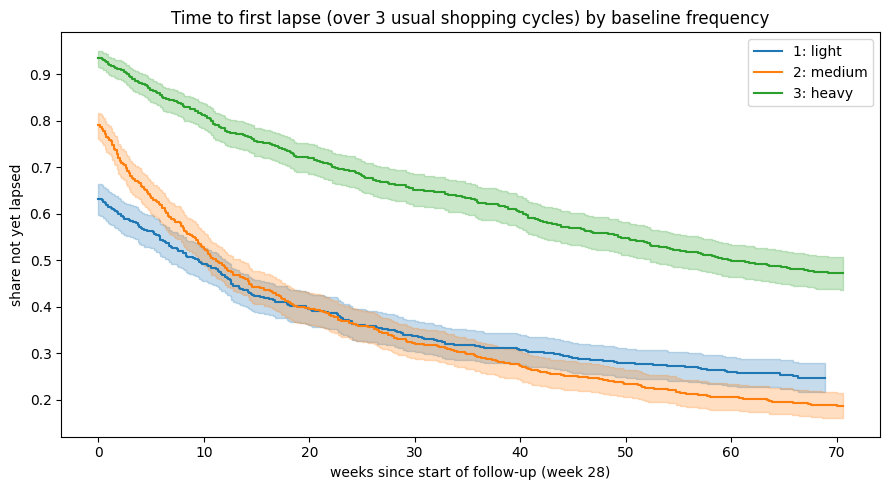

Log-rank test: chi2 = 217.0, p = 7.72e-48


,median_weeks_to_lapse,not_lapsed_at_13w_pct,not_lapsed_at_26w_pct,not_lapsed_at_52w_pct
1: light,9.428571,44.4,35.8,27.5
2: medium,11.142857,46.7,35.5,22.5
3: heavy,59.714286,77.2,67.3,53.7


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for tier, d in surv.groupby('frequency_tier'):
    KaplanMeierFitter().fit(d.weeks, d.lapsed, label=tier).plot_survival_function(ax=ax)
ax.set(xlabel='weeks since start of follow-up (week 28)', ylabel='share not yet lapsed', title='Time to first lapse (over 3 usual shopping cycles) by baseline frequency')
plt.tight_layout(); plt.savefig(FIG/'05_km_by_frequency.png', dpi=150); plt.show()
lr = multivariate_logrank_test(surv.weeks, surv.frequency_tier, surv.lapsed)
print(f"Log-rank test: chi2 = {lr.test_statistic:.1f}, p = {lr.p_value:.3g}")
km = {t: KaplanMeierFitter().fit(d.weeks, d.lapsed) for t, d in surv.groupby('frequency_tier')}
pd.DataFrame({t: {'median_weeks_to_lapse': m.median_survival_time_, **{f'not_lapsed_at_{w}w_pct': round(100 * m.predict(w), 1) for w in (13, 26, 52)}} for t, m in km.items()}).T

A median of `inf` means fewer than half of that tier lapsed during follow-up, so the median cannot be estimated.

## 5. Cox proportional hazards model
The Cox model estimates how each baseline behaviour changes the risk of lapsing at any point in time, holding the others fixed. A hazard ratio below 1 means lower risk.

Choices:
- **Stratified by frequency tier.** Each tier gets its own baseline risk curve, so the model compares households only with similar shoppers and does not need frequency to have a constant effect over time. Trips per week is left out as a predictor, because it already sets each household's threshold.
- **Standardised predictors**, so each hazard ratio is the effect of a 1 standard deviation increase and the effects are comparable.
- **Log transform** of basket value, because it is heavily skewed. Total spend is left out because spend is roughly trips times basket size, which would make the estimates unstable.

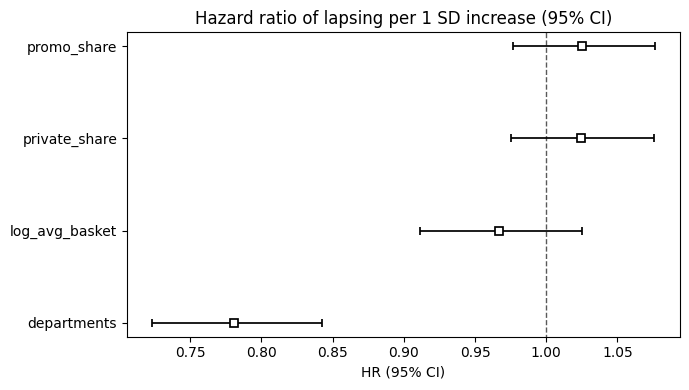

Concordance = 0.579


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
log_avg_basket,0.966,0.911,1.025,0.258
departments,0.781,0.723,0.842,0.000
private_share,1.024,0.976,1.076,0.334
promo_share,1.025,0.976,1.076,0.318


In [7]:
cox_df = surv[['weeks', 'lapsed', 'frequency_tier']].assign(
    log_avg_basket=np.log1p(surv.avg_basket), departments=surv.departments, private_share=surv.private_share, promo_share=surv.promo_share)
covs = cox_df.columns[3:]
cox_df[covs] = (cox_df[covs] - cox_df[covs].mean()) / cox_df[covs].std()
cph = CoxPHFitter().fit(cox_df, duration_col='weeks', event_col='lapsed', strata=['frequency_tier'])
fig, ax = plt.subplots(figsize=(7, 4))
cph.plot(hazard_ratios=True, ax=ax)
ax.set_title('Hazard ratio of lapsing per 1 SD increase (95% CI)')
plt.tight_layout(); plt.savefig(FIG/'05_cox_hazard_ratios.png', dpi=150); plt.show()
print(f"Concordance = {cph.concordance_index_:.3f}")
cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].round(3)

The concordance index is the share of household pairs whose lapse order the model ranks correctly. 0.5 is a coin flip. Because the model is stratified, this measures how well behaviour ranks households within the same frequency tier, so a modest value is expected.

### Checking the proportional hazards assumption
Cox assumes each predictor's effect is constant over time. The test below (based on Schoenfeld residuals) checks this for every predictor. With over 2,000 households, the test can flag very small, unimportant deviations, so a significant result is read together with the size of the hazard ratio rather than on its own.

In [8]:
proportional_hazard_test(cph, cox_df, time_transform='rank').summary.round(3)

,test_statistic,p,-log2(p)
departments,3.906,0.048,4.377
log_avg_basket,0.229,0.632,0.662
private_share,0.611,0.434,1.203
promo_share,0.213,0.644,0.634


## 6. Sensitivity check: 4 cycles instead of 3
If the conclusions hold when the lapse definition changes from 3 to 4 missed cycles, they do not depend on an arbitrary cut-off.

In [9]:
surv4 = q(f"SELECT l.*, b.frequency_tier FROM ({lapse_sql(4)}) l JOIN baseline b ON b.household_key = l.household_key").assign(weeks=lambda d: d.days / 7)
pd.DataFrame({f'{k} cycles': {t: round(100 * KaplanMeierFitter().fit(d.weeks, d.lapsed).predict(26), 1) for t, d in s.groupby('frequency_tier')}
              for k, s in ((3, surv), (4, surv4))}).rename_axis('not lapsed at 26 weeks (%)')

,3 cycles,4 cycles
not lapsed at 26 weeks (%),,
1: light,35.8,48.6
2: medium,35.5,48.8
3: heavy,67.3,67.3


## 7. Simple retention curve
For comparison with the survival view, the share of baseline households that shopped at least once in each 4-week period of follow-up. This is the measure most dashboards show, and it is kept for the Power BI report. Unlike the survival curve, it counts a household as retained again once it comes back after a break.

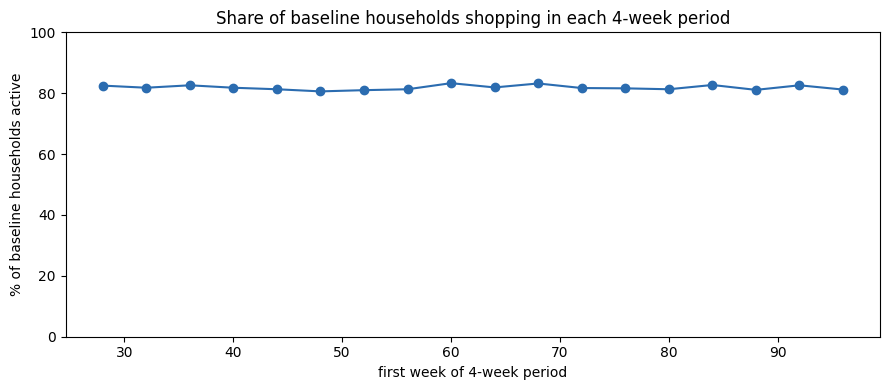

,period,first_week,active_households,active_pct
0,1,28,1923,82.5
1,2,32,1907,81.8
2,3,36,1925,82.6
3,4,40,1907,81.8
4,5,44,1894,81.3
5,6,48,1879,80.6
6,7,52,1888,81.0
7,8,56,1894,81.3
8,9,60,1940,83.3
9,10,64,1908,81.9


In [10]:
ret = q("""
WITH a AS (
  SELECT DISTINCT s.household_key, (s.week_no - 28) // 4 + 1 AS period
  FROM sales s
  JOIN baseline b ON b.household_key = s.household_key
  WHERE s.week_no BETWEEN 28 AND 99
)
SELECT period, 24 + 4 * period AS first_week, COUNT(*) AS active_households,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM baseline), 1) AS active_pct
FROM a
GROUP BY period
ORDER BY period
""")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ret.first_week, ret.active_pct, marker='o', color='#2b6cb0')
ax.set(xlabel='first week of 4-week period', ylabel='% of baseline households active', ylim=(0, 100), title='Share of baseline households shopping in each 4-week period')
plt.tight_layout(); plt.savefig(FIG/'05_retention_curve.png', dpi=150); plt.show()
ret

## 8. Save
One row per household with baseline features, frequency tier and lapse outcome, for the dashboard.

In [11]:
con.register('surv_df', surv[['household_key', 'days', 'lapsed', 'returned']])
con.execute(f"""
COPY (
  SELECT s.household_key, s.days AS days_to_lapse_or_censor, s.lapsed, s.returned, b.*  EXCLUDE (household_key)
  FROM surv_df s
  JOIN baseline b ON b.household_key = s.household_key
) TO '{DATA}/household_lapse.parquet' (FORMAT PARQUET)
""")
q(f"SELECT COUNT(*) AS households, SUM(lapsed::INT) AS lapsed, SUM(returned::INT) AS returned FROM '{DATA}/household_lapse.parquet'")

,households,lapsed,returned
0,2330,1623.0,1594.0


## Findings

1. **The personal threshold fixed the lapse definition.** Only 1.1% of heavy shoppers' visit gaps exceed 23 days, against 16.3% for light shoppers, so a single threshold would treat ordinary light-shopper behaviour as lapsing. Light households now get a median threshold of 63 days, while medium and heavy households sit at the 23-day floor.
2. **Breaks are common, permanent churn is rare.** 1,623 of the 2,330 baseline households (70%) had at least one break from their rhythm during the 74 weeks of follow-up, but 1,594 of them (98%) came back. Only 29 households (1.2%) never returned. The simple retention curve confirms this: 81 to 83% of baseline households shop in every 4-week period, with no downward trend.
3. **Heavy shoppers keep their rhythm far longer.** 67% of heavy households had not yet had a break after 26 weeks, against about 36% of light and medium households. The median time to a first break is 60 weeks for heavy shoppers and 9 to 11 weeks for the others (log-rank p < 0.001).
4. **Breadth of shop is the one behaviour linked to fewer breaks.** Within the same frequency tier, households that bought from more departments in the baseline had a 22% lower break risk per standard deviation (hazard ratio 0.78, 95% CI 0.72 to 0.84). Basket size, private label share and promotion share had no measurable effect. The concordance of 0.58 is modest, as expected for a within-tier comparison. The proportional hazards test is borderline for departments (p = 0.043), which is minor with 2,330 households and does not change the direction of the effect.
5. **The conclusions hold under a stricter definition.** With a 4-cycle rule, light and medium households rise from about 36% to 49% not lapsed at 26 weeks, while heavy households stay at 67% because their threshold is set by the 23-day floor. The ranking of the tiers does not change.

**Limitations:** baseline tiers come from only 12 weeks, so some households are misclassified. Over the full period, light-tier households have a median visit gap of 7 days, much shorter than their baseline rate suggests, which points to regression to the mean. The breadth effect is an association: households that shop broadly may simply be more committed, rather than broad shopping causing loyalty.

## Recommendations
1. **Manage breaks, not churn.** With only 1.2% of households lost for good, a broad churn-prevention budget would mostly reward customers who were coming back anyway. The money is better spent shortening breaks.
2. **Trigger reminders on each household's own rhythm.** A single "no visit in 30 days" rule fires far too late for heavy shoppers and too early for light ones. Sending a reminder once a household misses about 3 of its usual cycles (at least 23 days) catches breaks when they are unusual for that customer.
3. **Use breadth of shop as an early-warning signal and a retention lever.** Households buying from few departments are more likely to break their routine. Cross-category offers for narrow shoppers, tested against a hold-out group, would show whether widening the basket also reduces breaks.
4. **Watch heavy shoppers most closely.** They break their rhythm least often, but each break costs the most revenue, and the 23-day floor is the right alarm point for them. The `threshold_days` column in `household_lapse.parquet` gives the CRM team each household's personal trigger.